In [1]:
%pip install split-folders


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import shutil
import splitfolders
import tensorflow as tf
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix


os.environ['KAGGLE_USERNAME'] = "sannidhyabiswas"
os.environ['KAGGLE_KEY'] = "KGAT_2352de914187ac8b2d3fe17a9913c07a"

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    'binary_dataset',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    'binary_dataset',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 455 images belonging to 2 classes.
Found 112 images belonging to 2 classes.


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/Users/sannidhyabiswas/Documents/Projekts/DeepDent AI/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 469ms/step - accuracy: 0.9670 - loss: 0.2894 - val_accuracy: 0.9911 - val_loss: 0.1031
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 435ms/step - accuracy: 0.9824 - loss: 0.1166 - val_accuracy: 0.9911 - val_loss: 0.0547
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 449ms/step - accuracy: 0.9824 - loss: 0.0959 - val_accuracy: 0.9911 - val_loss: 0.0518
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 450ms/step - accuracy: 0.9824 - loss: 0.0957 - val_accuracy: 0.9911 - val_loss: 0.0522
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 456ms/step - accuracy: 0.9824 - loss: 0.0950 - val_accuracy: 0.9911 - val_loss: 0.0511
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 464ms/step - accuracy: 0.9824 - loss: 0.0998 - val_accuracy: 0.9911 - val_loss: 0.0534
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 463ms/step - accuracy: 0.9824 - loss: 0.0918 - val_accuracy: 0.9911 - val_loss: 0.0724
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 465ms/step - accuracy: 0.9824 - loss: 0.0976 - val_accuracy: 0.

In [6]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

model.save('deepdent_model.h5')

NameError: name 'validation_generator' is not defined

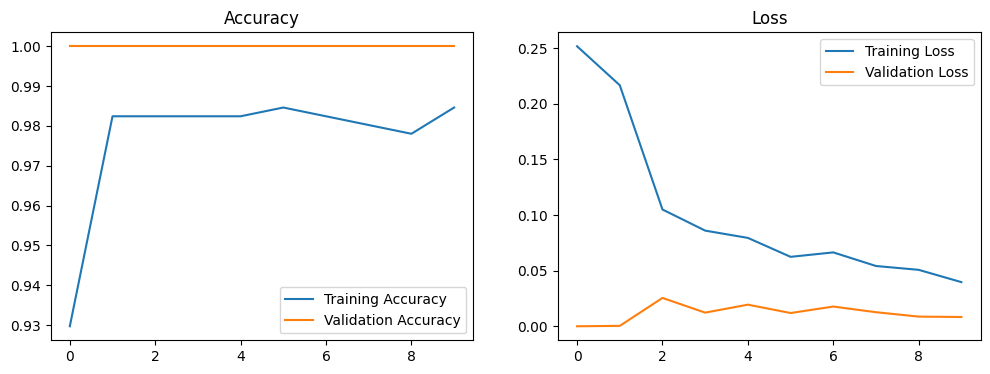

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
DeepDent Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        23

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



/Users/sannidhyabiswas/Documents/Projekts/DeepDent AI/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


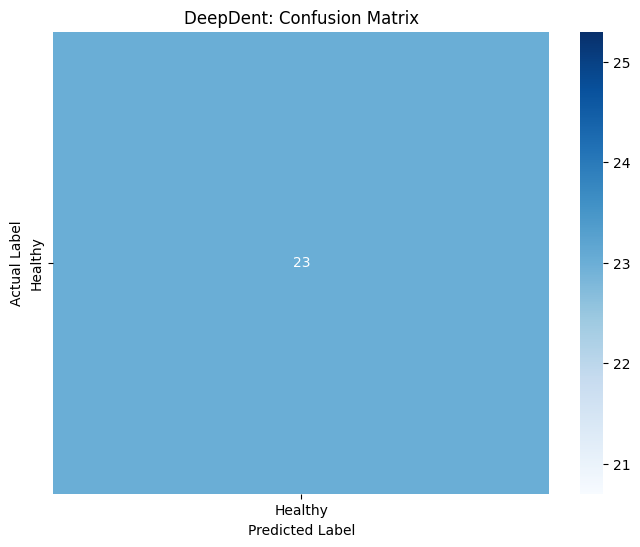

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# 1. Reset and Predict
validation_generator.reset()
Y_pred = model.predict(validation_generator)
y_pred = (Y_pred > 0.5).astype(int).flatten()
y_true = validation_generator.classes

# 2. Check how many classes are actually present
unique_classes = np.unique(y_true)
if len(unique_classes) == 1:
    target_names = ['Healthy'] if unique_classes[0] == 0 else ['Decay']
else:
    target_names = ['Healthy', 'Decay']

# 3. Print Report
print("DeepDent Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, labels=unique_classes))

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('DeepDent: Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

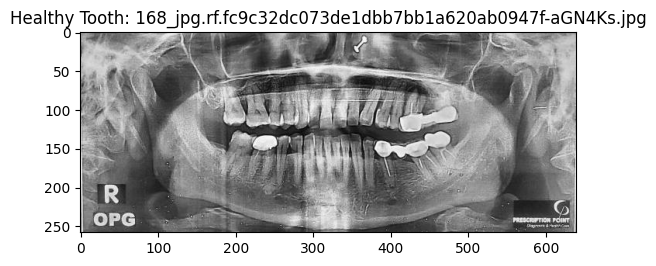

Test this file in your app: raw_data/Dental OPG XRAY Dataset/Augmented_Data/train/images/168_jpg.rf.fc9c32dc073de1dbb7bb1a620ab0947f-aGN4Ks.jpg


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

img_dir = 'raw_data/Dental OPG XRAY Dataset/Augmented_Data/train/images'
lbl_dir = 'raw_data/Dental OPG XRAY Dataset/Augmented_Data/train/labels'

# Find images that don't have a matching .txt file
all_imgs = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]
healthy_imgs = [f for f in all_imgs if not os.path.exists(os.path.join(lbl_dir, f.replace('.jpg', '.txt').replace('.png', '.txt')))]

if healthy_imgs:
    img_path = os.path.join(img_dir, healthy_imgs[0])
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Healthy Tooth: {healthy_imgs[0]}")
    plt.show()
    print(f"Test this file in your app: {img_path}")
else:
    print("No unlabeled (healthy) images found in this folder.")

In [ ]:
import os
import shutil

# Paths based on your uploaded files
raw_img_dir = 'raw_data/Dental OPG XRAY Dataset/Augmented_Data/train/images'
raw_lbl_dir = 'raw_data/Dental OPG XRAY Dataset/Augmented_Data/train/labels'
base_dir = 'binary_dataset'

os.makedirs(f'{base_dir}/healthy', exist_ok=True)
os.makedirs(f'{base_dir}/decay', exist_ok=True)

for img_name in os.listdir(raw_img_dir):
    if img_name.endswith(('.jpg', '.png')):
        txt_name = img_name.rsplit('.', 1)[0] + '.txt'
        src = os.path.join(raw_img_dir, img_name)
        
        # If a .txt file exists, it's Decay. If not, it's Healthy.
        if os.path.exists(os.path.join(raw_lbl_dir, txt_name)):
            shutil.copy(src, f'{base_dir}/decay/{img_name}')
        else:
            shutil.copy(src, f'{base_dir}/healthy/{img_name}')

print(f"Decay images: {len(os.listdir(base_dir+'/decay'))}")
print(f"Healthy images: {len(os.listdir(base_dir+'/healthy'))}")

Decay images: 558
Healthy images: 9


In [ ]:
model.save('deepdent_model.h5')